# Lesson 3

This is an interactive notebook on supervised learning.
We will cover Regression, Bias-Variance trade off, Logistic Regression and K-nearest neighbors.

You need to install `Numpy`, `Pandas`, `seaborn`, `scikit-learn` packages in order to run the notebook



---

All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University (i.e., Nanyang Technological University), unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---

# Supervised Learning: Regression

In statistical modeling, regression analysis is a set of statistical processes for estimating the relationships between a dependent variable (often called the 'outcome' or 'response' variable, or a 'label' in machine learning parlance) and one or more independent variables (often called 'predictors', 'covariates', 'explanatory variables' or 'features'). The most common form of regression analysis is linear regression, in which one finds the line (or a more complex linear combination) that most closely fits the data according to a specific mathematical criterion.

https://en.wikipedia.org/wiki/Supervised_learning

https://en.wikipedia.org/wiki/Regression_analysis

SciKit-learn toolkit is a simple and efficient tool for predictive data analysis. It is accessible to everybody, and reusable in various contexts and built on NumPy, SciPy, and matplotlib.

https://scikit-learn.org/


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200

import numpy as np
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

plt.style.use('ggplot')

## Linear Regression: Diabetes (from sklearn)

For this tutorial, we will study the diabetes dataset that is built-in to scikit-learn. 

Ten baseline variables, age, sex, body mass index, average blood pressure, and six blood serum measurements were obtained for each of n = 442 diabetes patients, as well as the response of interest, a quantitative measure of disease progression one year after baseline.

In [2]:
# Load the diabetes dataset
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [3]:
print(diabetes.data.shape)

(442, 10)


The DESCR variable has a long description of the dataset:

In [4]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [5]:
print ('Diabetes data')
print ('  Type: ' + str(type(diabetes.data)))
print ('  Shape: ' + str(diabetes.data.shape))
print ('Diabetes target')
print ('  Type: ' + str(type(diabetes.target)))
print ('  Shape: ' + str(diabetes.target.shape))

Diabetes data
  Type: <class 'numpy.ndarray'>
  Shape: (442, 10)
Diabetes target
  Type: <class 'numpy.ndarray'>
  Shape: (442,)


In [6]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [7]:
diabetes.data

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [8]:
diabetes.data.shape

(442, 10)

In [9]:
diabetes.data[0:10,:]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087],
       [-0.09269548, -0.04464164, -0.04069594, -0.01944183, -0.06899065,
        -0.07928784,  0.04127682, -0.0763945 , -0.04117617, -0.09634616],
       [-0.04547248,  0.05068012, -0.04716281, -0.01599898, -0.04009564,
        -0.02480001,  0.00077881, -0.03949338

#### With matplotlib

let us show a histogram of the target values: quantitative measure of disease progression one year after baseline

(array([38., 80., 68., 62., 50., 41., 38., 42., 17.,  6.]),
 array([ 25. ,  57.1,  89.2, 121.3, 153.4, 185.5, 217.6, 249.7, 281.8,
        313.9, 346. ]),
 <BarContainer object of 10 artists>)

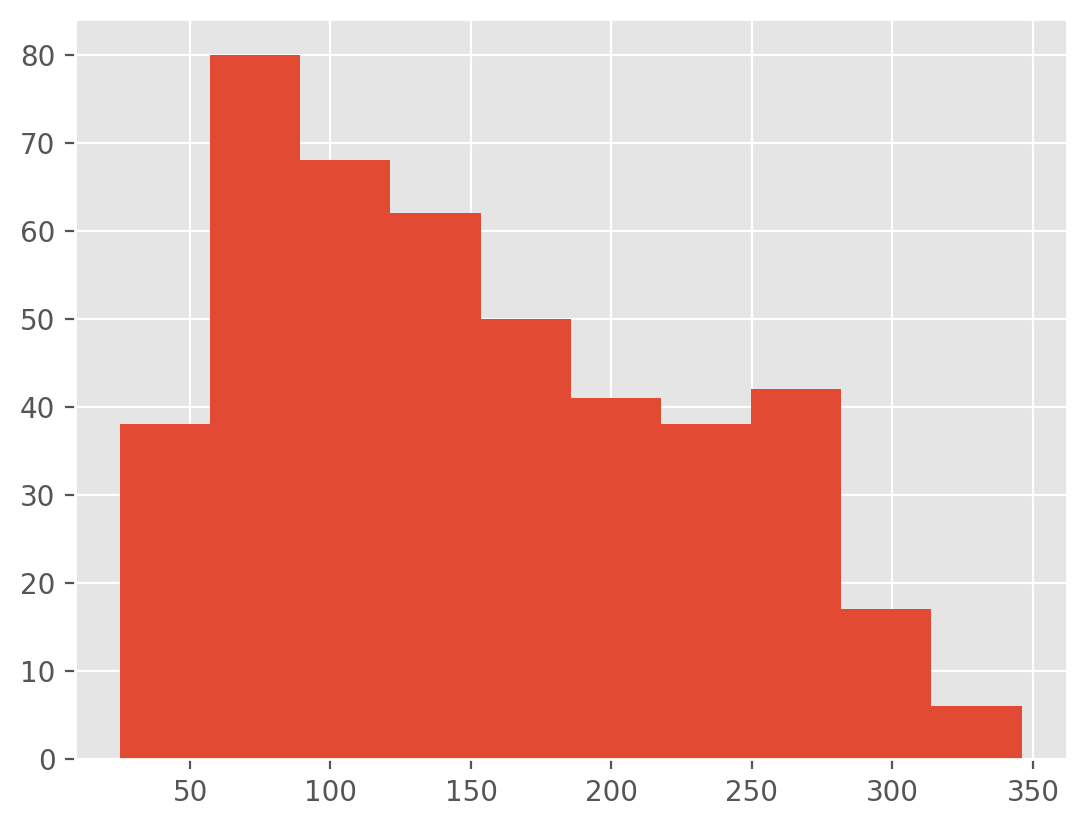

In [10]:
plt.hist(diabetes.target) 

Let’s have a quick look to see if some features are more relevant than others for our problem:


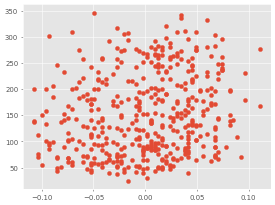

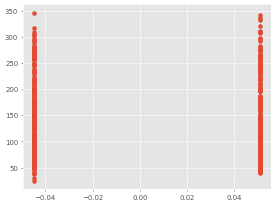

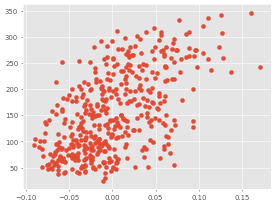

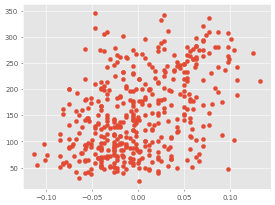

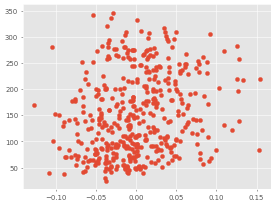

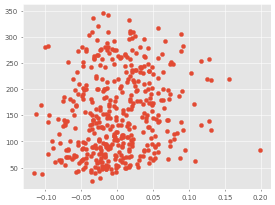

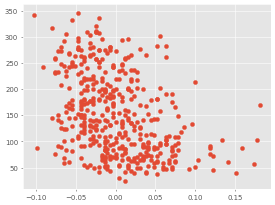

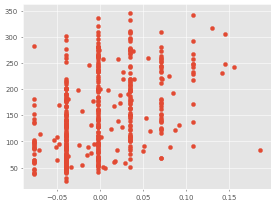

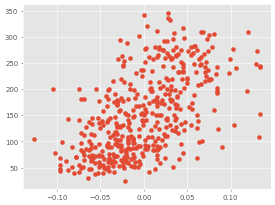

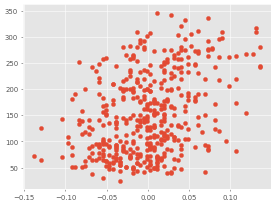

In [11]:
plt.rcParams['figure.dpi'] = 50

for index, feature_name in enumerate(diabetes.feature_names):
    plt.figure()
    plt.scatter(diabetes.data[:, index], diabetes.target)  

Now we’ll use scikit-learn to perform a simple linear regression on the diabetes data. There are many possibilities of regressors to use. A particularly simple one is LinearRegression: this is basically a wrapper around an ordinary least squares calculation.

In [12]:
# Split train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=0)

In [13]:
# Create linear regression object
model = LinearRegression()

In [14]:
# Train the model using the training sets
model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Get the coefficients
model.coef_

array([ -35.55025079, -243.16508959,  562.76234744,  305.46348218,
       -662.70290089,  324.20738537,   24.74879489,  170.3249615 ,
        731.63743545,   43.0309307 ])

In [16]:
# Get the intercept
model.intercept_ 

152.5380470138517

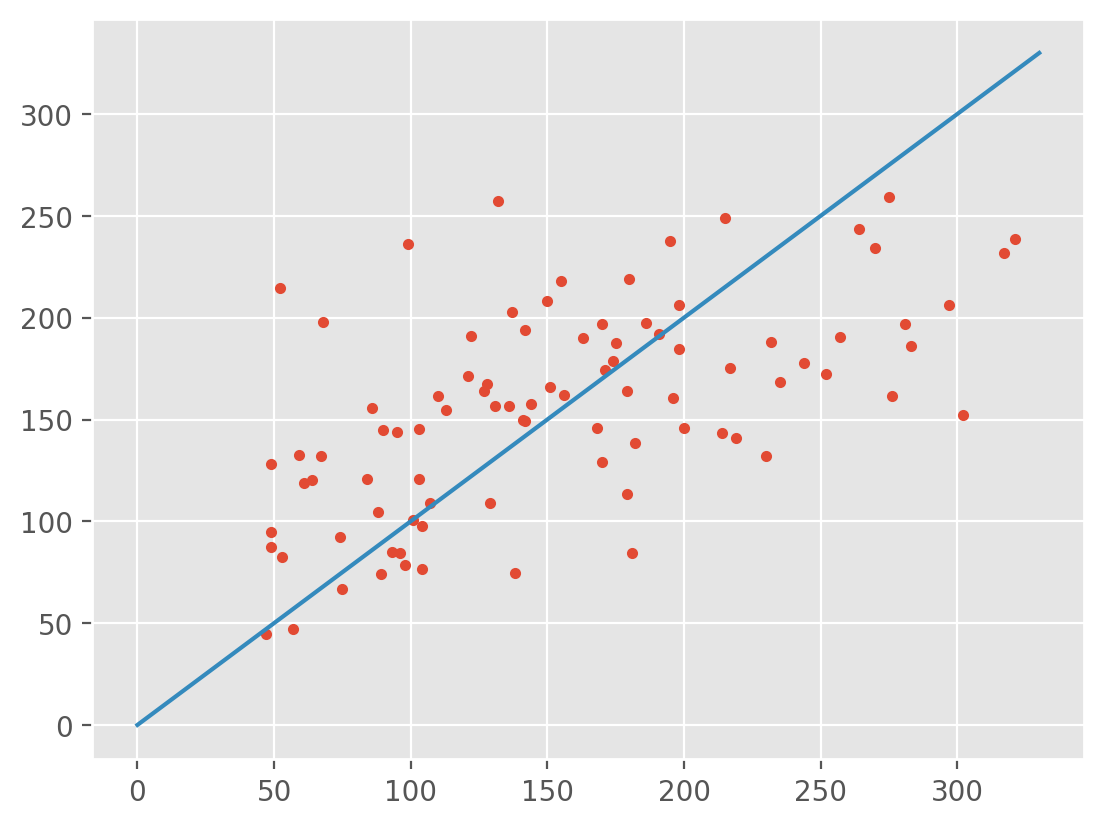

In [17]:
plt.rcParams['figure.dpi'] = 200

# plot prediction and actual data
y_pred = model.predict(X_test) 
plt.plot(y_test, y_pred, '.')

# plot a line, a perfit predict would all fall on this line
x = np.linspace(0, 330, 100)
y = x
plt.plot(x, y)
plt.show()

In [18]:
print("RMS: %s" % np.sqrt(np.mean((y_pred - y_test) ** 2))) 

RMS: 58.517171277315626


## Beyond Linear Regression:  Bias Variance trade-off

This example demonstrates the problems of underfitting and overfitting and how we can use linear regression with polynomial features to approximate nonlinear functions. The plot shows the function that we want to approximate, which is a part of the cosine function. In addition, the samples from the real function and the approximations of different models are displayed. The models have polynomial features of different degrees. We can see that a linear function (polynomial with degree 1) is not sufficient to fit the training samples. This is called underfitting. A polynomial of degree 4 approximates the true function almost perfectly. However, for higher degrees the model will overfit the training data, i.e. it learns the noise of the training data. We evaluate quantitatively overfitting / underfitting by using cross-validation. We calculate the mean squared error (MSE) on the validation set, the higher, the less likely the model generalizes correctly from the training data.

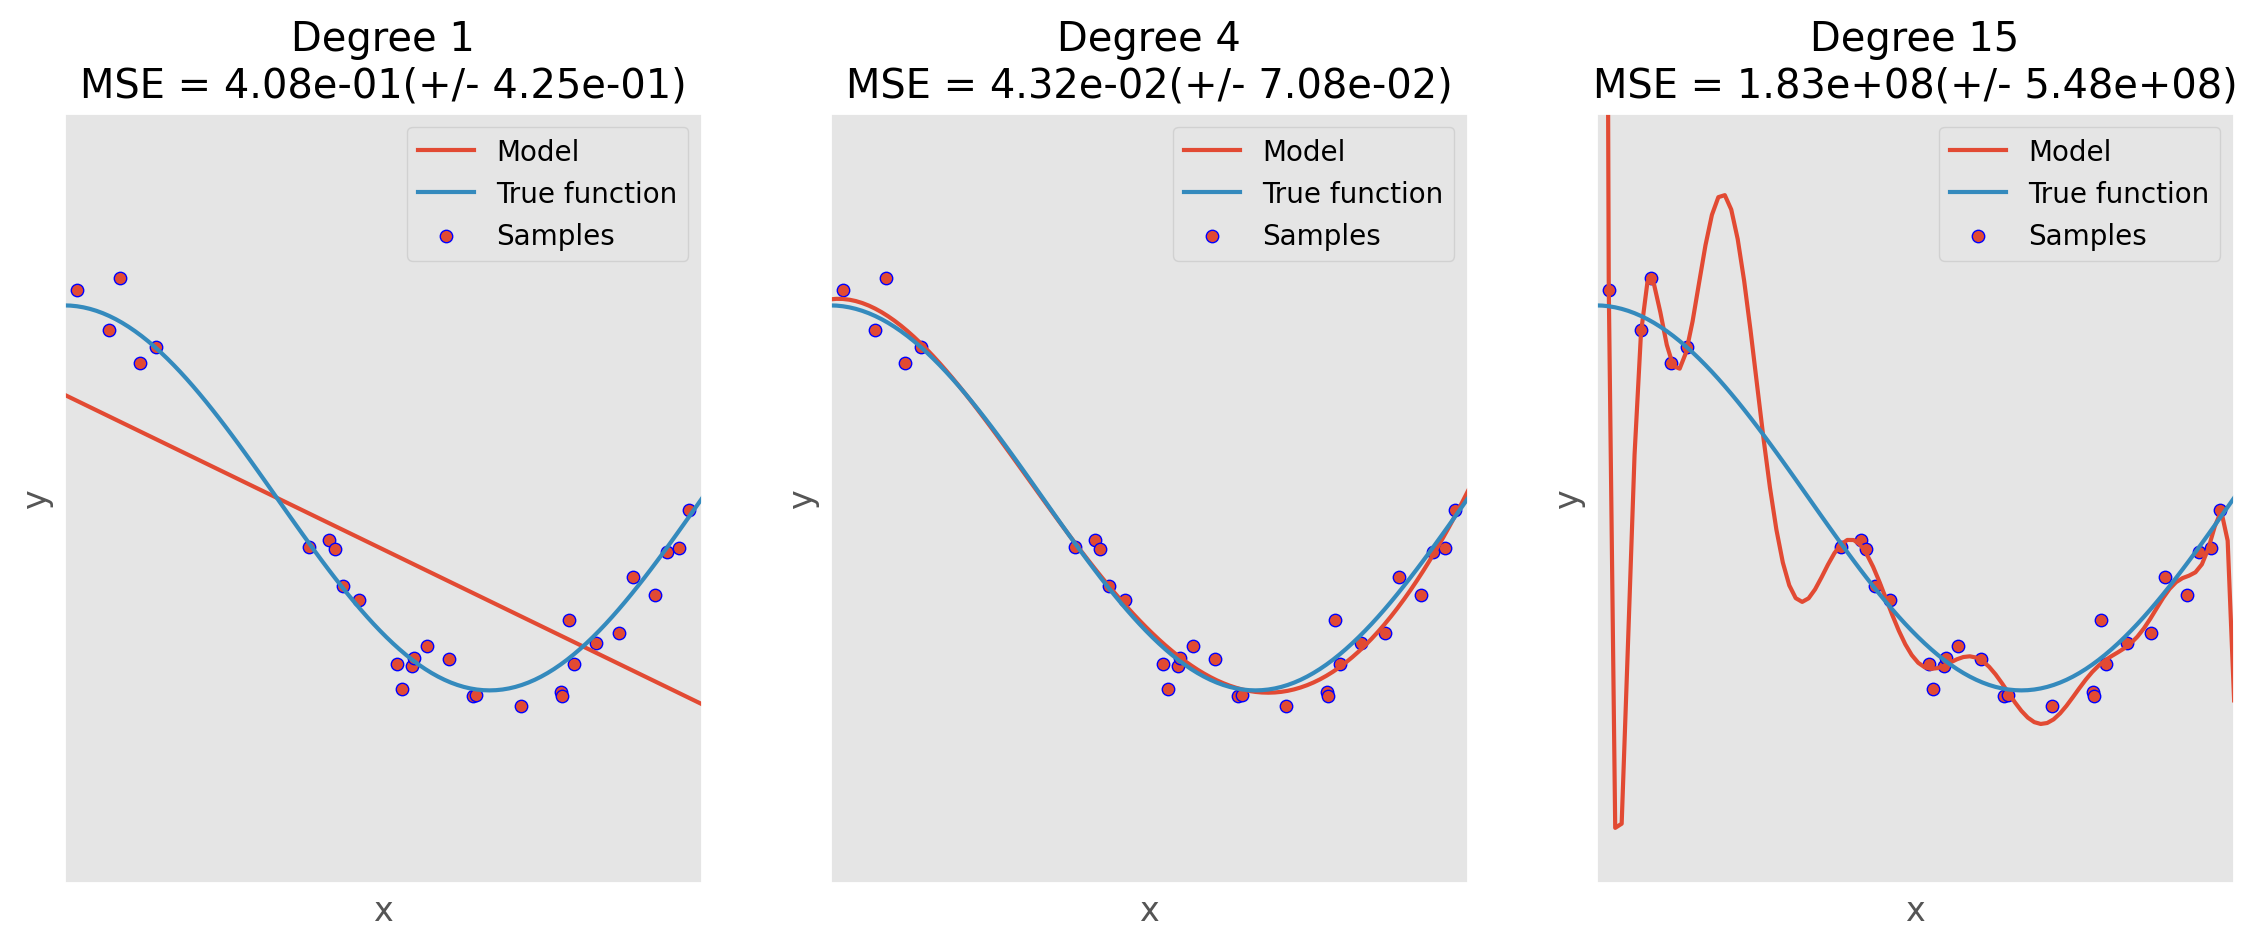

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(
        pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10
    )

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor="b", s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(
        "Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
            degrees[i], -scores.mean(), scores.std()
        )
    )
plt.show()

---

## Recognizing hand-written digits

The digits dataset consists of 8x8
pixel images of digits. The ``images`` attribute of the dataset stores
8x8 arrays of grayscale values for each image. We will use these arrays to
visualize the first 4 images. The ``target`` attribute of the dataset stores
the digit each image represents and this is included in the title of the 4
plots below.

Note: if we were working from image files (e.g., 'png' files), we would load
them using :func:`matplotlib.pyplot.imread`.




Here we look at classifying digits using the logistic regression. We will represent input image as a vector $\mathbf{x} \in \mathbb{R}^N$. The goal is to learn a classifier $h(\mathbf{x})$ such that

$h(\mathbf{x}) = y \in \{ 0,1,2,...,9\}$.


---
### Digit classification using Logistic Regression

In [20]:
from sklearn.datasets import load_digits
digits = load_digits()

In [21]:
print("Label Data Shape", digits.target.shape)

Label Data Shape (1797,)


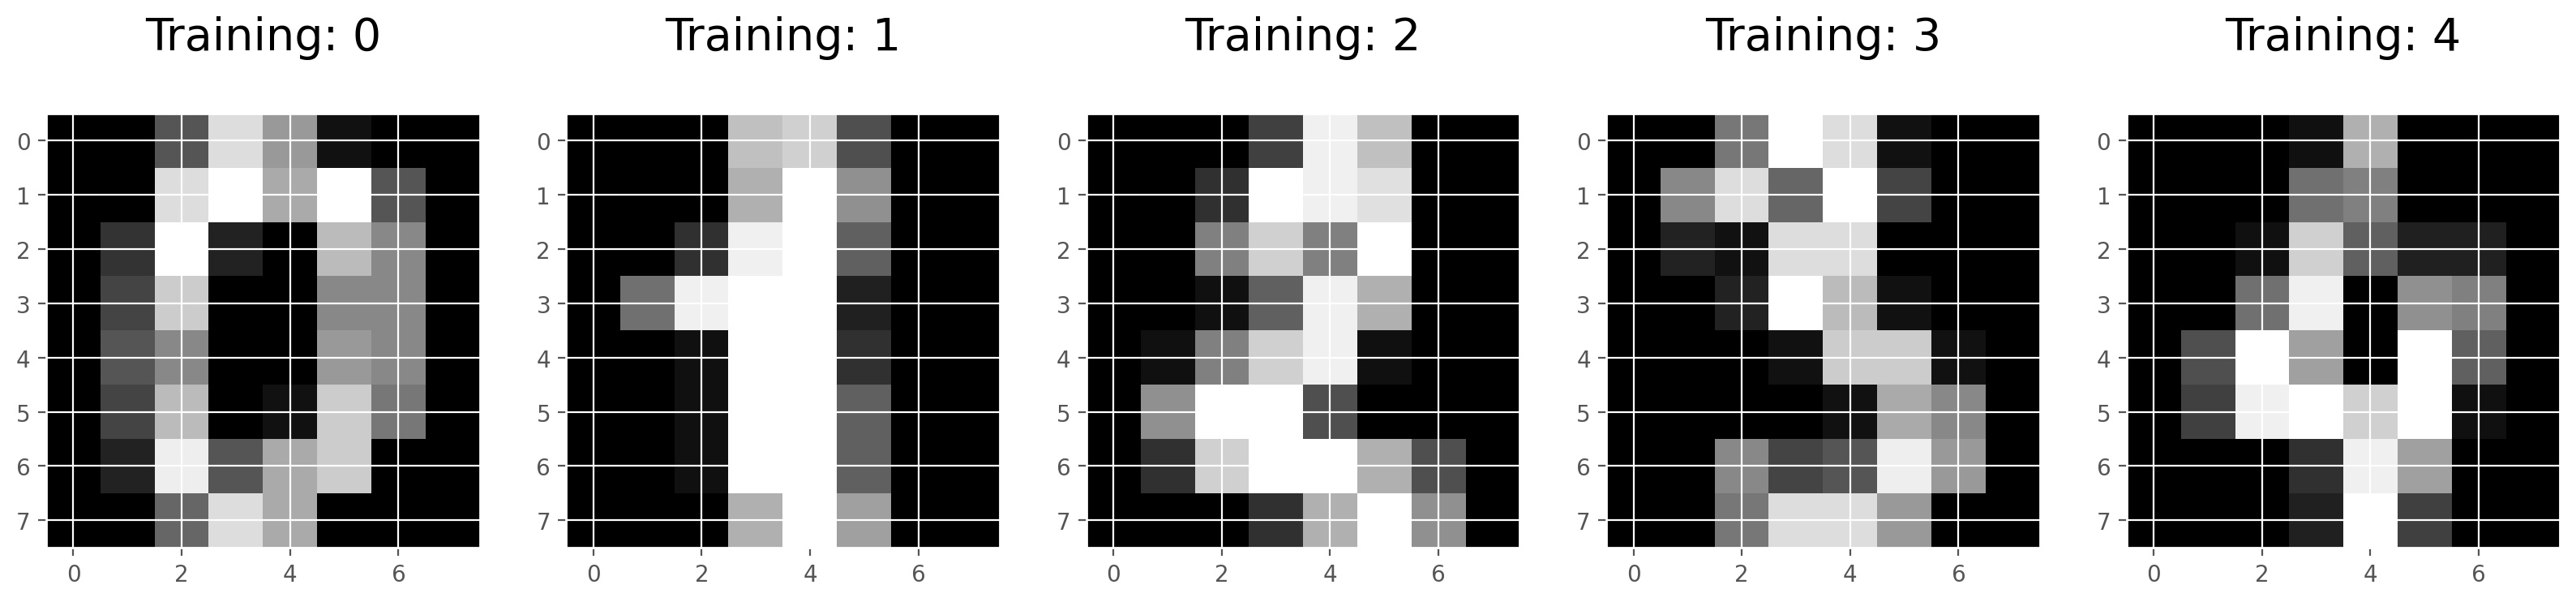

In [22]:
plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
  plt.subplot(1, 5, index + 1)
  plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
  plt.title('Training: %i\n' % label, fontsize = 20)

In [23]:
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=0)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
# all parameters not specified are set to their defaults
logisticRegr = LogisticRegression(max_iter=10000)

In [26]:
logisticRegr.fit(x_train, y_train)

LogisticRegression(max_iter=10000)

In [27]:
predictions = logisticRegr.predict(x_test)
print(
    "LogisticRegression score: %f"
    % logisticRegr.fit(x_train, y_train).score(x_test, y_test)
)

LogisticRegression score: 0.958333


In [28]:
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions)
print(cm)

[[27  0  0  0  0  0  0  0  0  0]
 [ 0 31  0  0  0  0  1  0  2  1]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  3]
 [ 0  1  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  1  0  0 38  0  0]
 [ 0  2  1  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  1 39]]


# Classification using KNN

## Nearest Neighbors Classification

Neighbors-based classification is a type of instance-based learning or non-generalizing learning: it does not attempt to construct a general internal model, but simply stores instances of the training data. Classification is computed from a simple majority vote of the nearest neighbors of each point: a query point is assigned the data class which has the most representatives within the nearest neighbors of the point.

## KNN

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

The k-neighbors classification in `KNeighborsClassifier` is the most commonly used technique. The optimal choice of the value  is highly data-dependent: in general a larger k suppresses the effects of noise, but makes the classification boundaries less distinct.

Sample usage of Nearest Neighbors classification on the Iris dataset. It will plot the decision boundaries for each class.

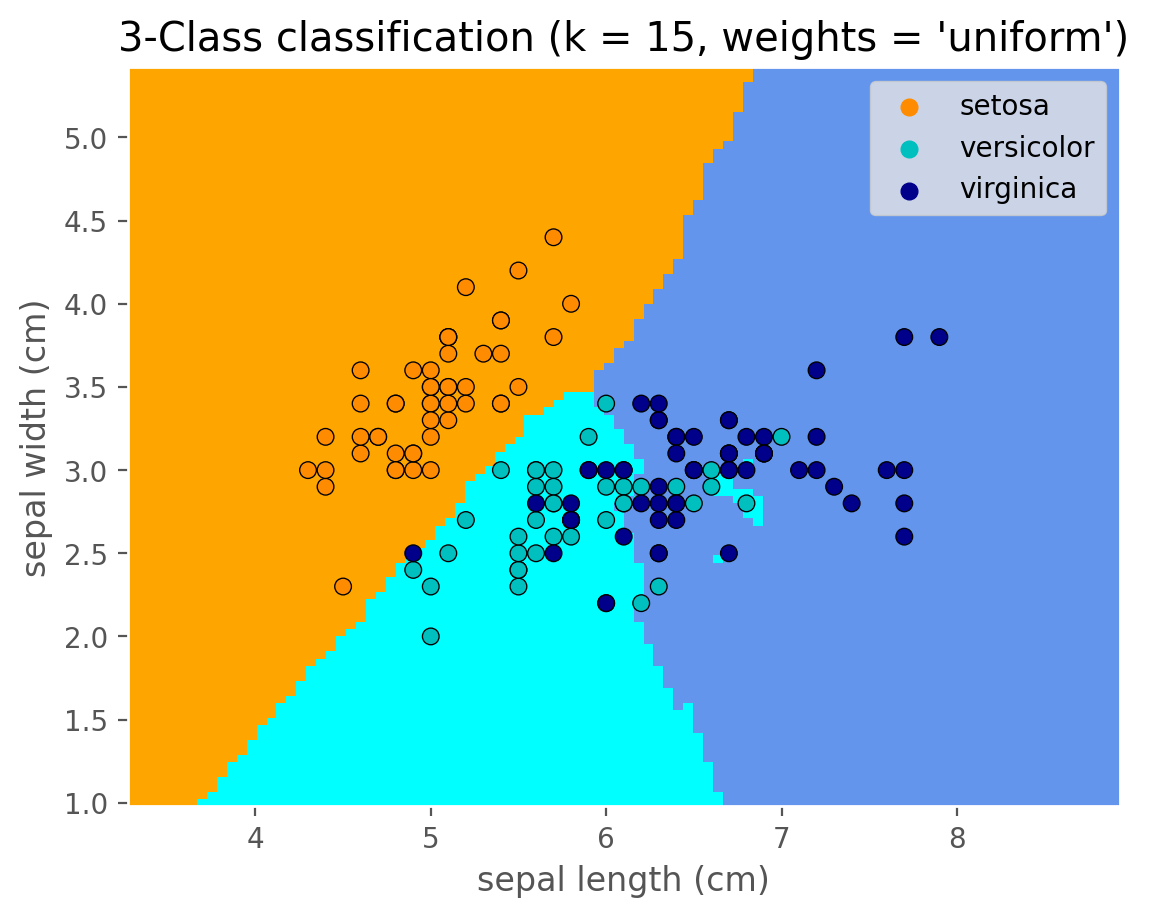

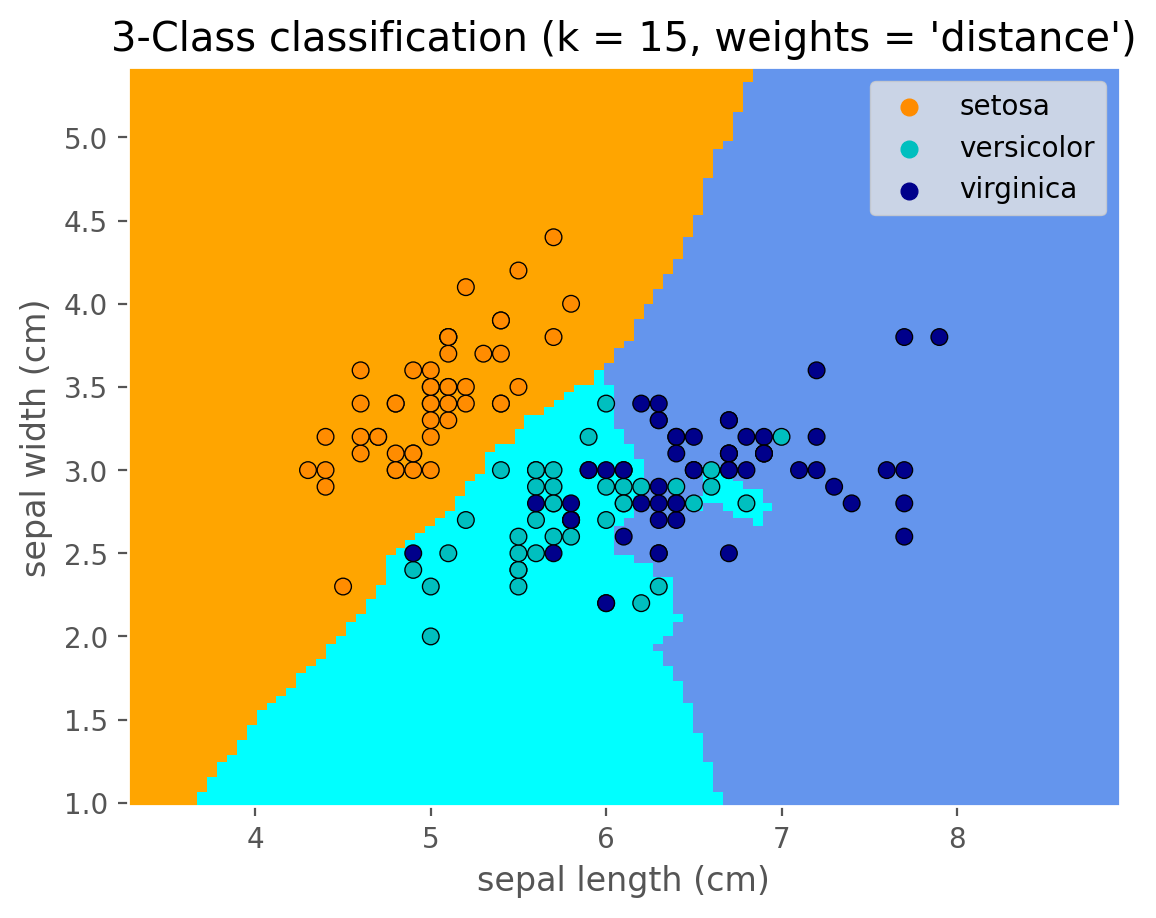

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.inspection import DecisionBoundaryDisplay

n_neighbors = 15

# import some data to play with
iris = datasets.load_iris()

# we only take the first two features. We could avoid this ugly
# slicing by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# Create color maps
cmap_light = ListedColormap(["orange", "cyan", "cornflowerblue"])
cmap_bold = ["darkorange", "c", "darkblue"]

for weights in ["uniform", "distance"]:
    # we create an instance of Neighbours Classifier and fit the data.
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X, y)

    _, ax = plt.subplots()
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=cmap_light,
        ax=ax,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
    )

    # Plot also the training points
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=iris.target_names[y],
        palette=cmap_bold,
        alpha=1.0,
        edgecolor="black",
    )
    plt.title(
        "3-Class classification (k = %i, weights = '%s')" % (n_neighbors, weights)
    )

plt.show()

### Digit dataset

In [30]:
from sklearn import datasets, neighbors, linear_model

X_digits, y_digits = datasets.load_digits(return_X_y=True)
X_digits = X_digits / X_digits.max()

n_samples = len(X_digits)

X_train = X_digits[: int(0.9 * n_samples)]
y_train = y_digits[: int(0.9 * n_samples)]
X_test = X_digits[int(0.9 * n_samples) :]
y_test = y_digits[int(0.9 * n_samples) :]

knn = neighbors.KNeighborsClassifier(10)
logistic = linear_model.LogisticRegression(max_iter=1000)

print("KNN score: %f" % knn.fit(X_train, y_train).score(X_test, y_test))
print(
    "LogisticRegression score: %f"
    % logistic.fit(X_train, y_train).score(X_test, y_test)
)

KNN score: 0.961111
LogisticRegression score: 0.933333


In [31]:
knn = neighbors.KNeighborsClassifier(1)
print("KNN score: %f" % knn.fit(X_train, y_train).score(X_train, y_train))

KNN score: 1.000000


Try to select the best value for k in a k-nearest neighbors classifier.

In [32]:
# Load libraries
from sklearn.neighbors import KNeighborsClassifier 
from sklearn import datasets
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline, FeatureUnion 
from sklearn.model_selection import GridSearchCV


# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
    
# Create standardizer
standardizer = StandardScaler() # Standardize features
features_standardized = standardizer.fit_transform(features) # Create a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # Create a pipeline
pipe = Pipeline([("standardizer", standardizer), ("knn", knn)]) # Create space of candidate values
search_space = [{"knn__n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}]
    
# Create grid search
classifier = GridSearchCV(pipe, search_space, cv=5, verbose=0).fit(features_standardized, target)

In [33]:
# Best neighborhood size (k)
classifier.best_estimator_.get_params()["knn__n_neighbors"]

6